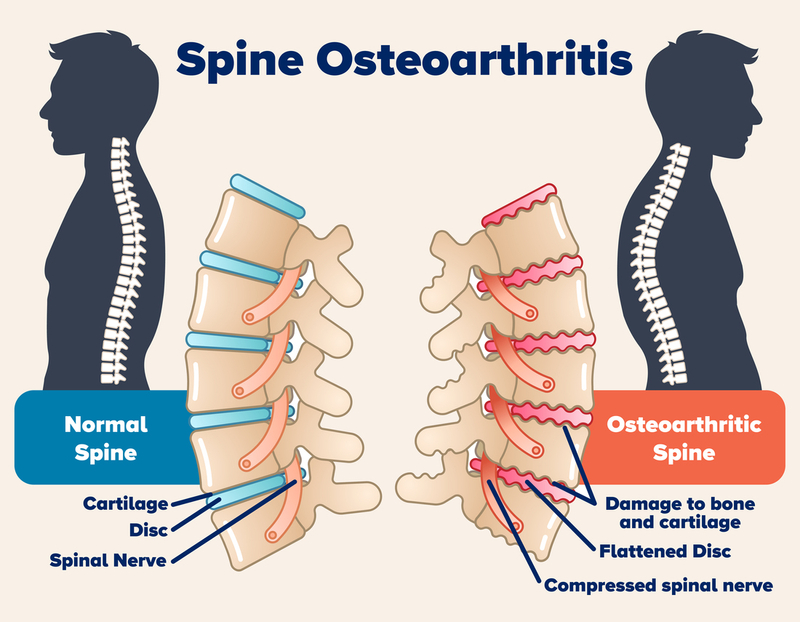

# 🧠 **Spine Condition Prediction Classification Project**

### **1. Problem Statement**
The objective is to classify whether a patient's spine is **Normal** or **Abnormal** based on various medical attributes.


### **2. Objective**

Spinal health issues can be detected through various medical measurements such as pelvic tilt, sacral slope, and lumbar lordosis angle.
This project aims to automate the classification of spine conditions using structured clinical data, enabling faster diagnosis support.

### **3. Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import pickle
import warnings
warnings.filterwarnings("ignore")

### **4. Data Loading**

In [2]:
df = pd.read_csv("C:\\Users\\DELL\\Documents\\Data Science\\CSV\\Dataset_spine.csv")
df.head(5)

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis,Class_att
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal


### **5. Data Understanding (EDA)**

In [3]:
df.shape

(310, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   pelvic incidence             310 non-null    float64
 1    pelvic tilt                 310 non-null    float64
 2    lumbar lordosis angle       310 non-null    float64
 3    sacral slope                310 non-null    float64
 4    pelvic radius               310 non-null    float64
 5    grade of spondylolisthesis  310 non-null    float64
 6   Class_att                    310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 17.1+ KB


In [5]:
df.describe()

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


In [6]:
# Check missing values

df.isnull().sum()

pelvic incidence               0
 pelvic tilt                   0
 lumbar lordosis angle         0
 sacral slope                  0
 pelvic radius                 0
 grade of spondylolisthesis    0
Class_att                      0
dtype: int64

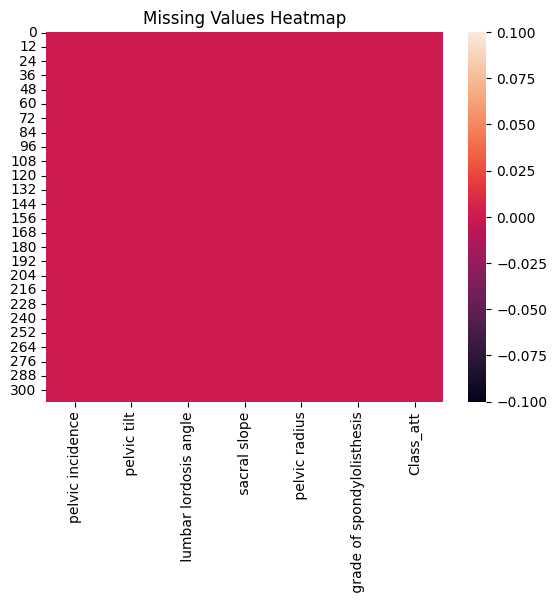

In [7]:
# Visualize missing values

sns.heatmap(df.isnull())
plt.title("Missing Values Heatmap")
plt.show()

### **4. Data Visualization**

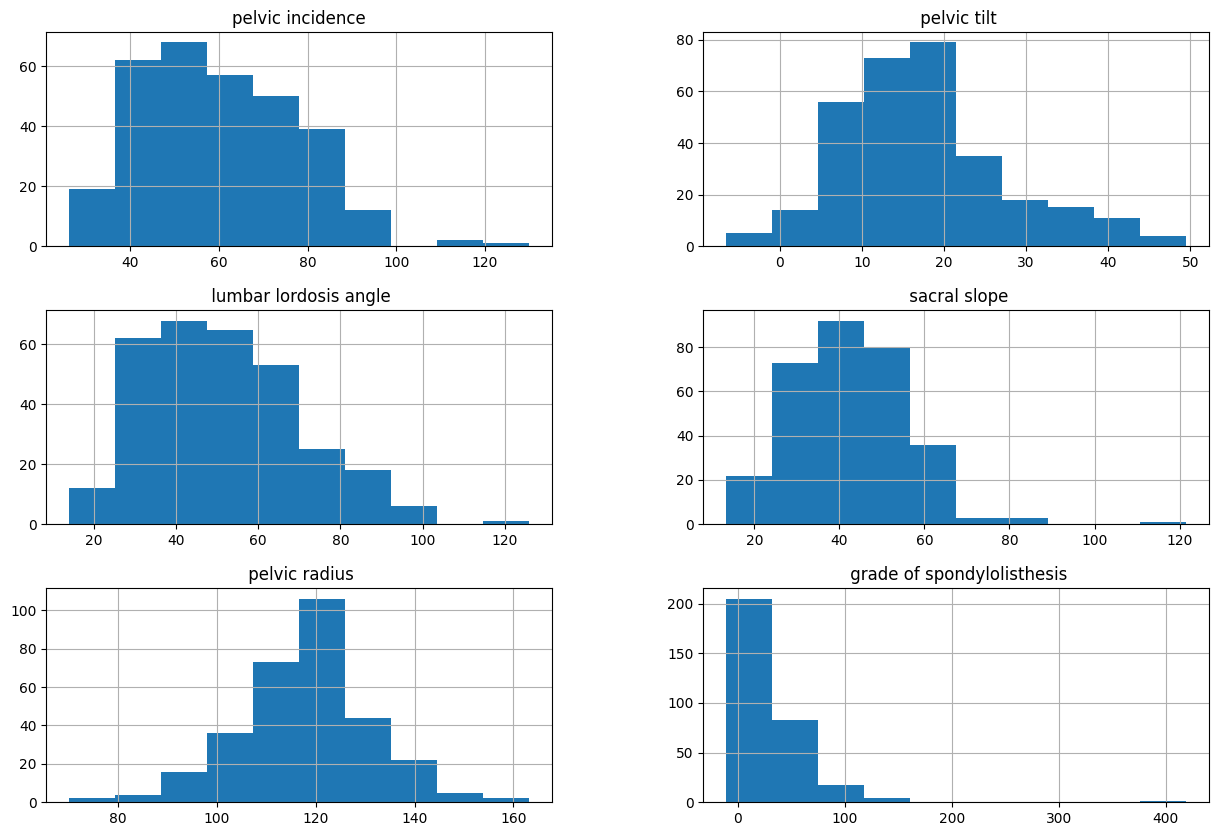

In [8]:
# Visualize feature distributions

df.hist(figsize=(15,10))
plt.show()

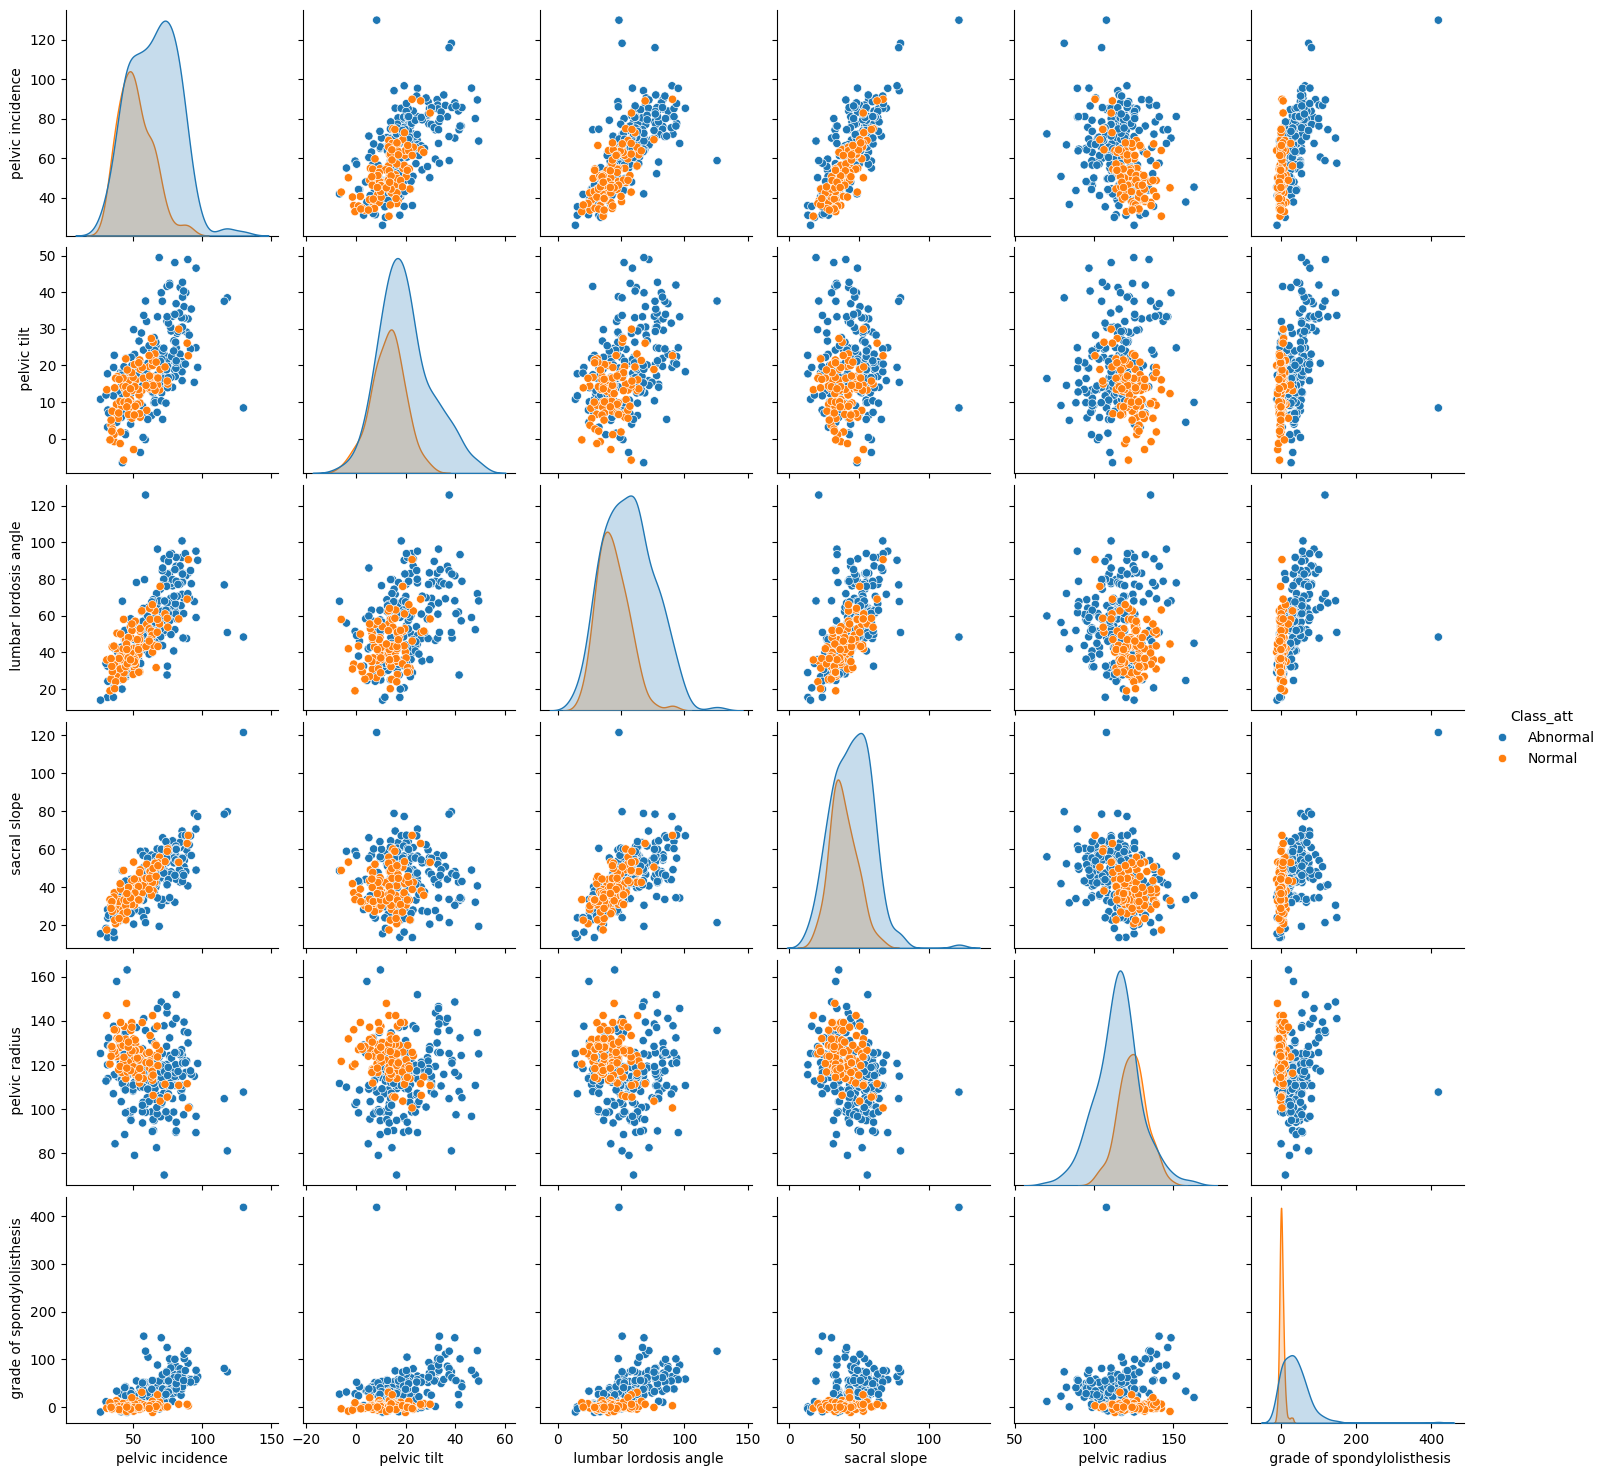

In [9]:
sns.pairplot(data=df, hue="Class_att")
plt.show()

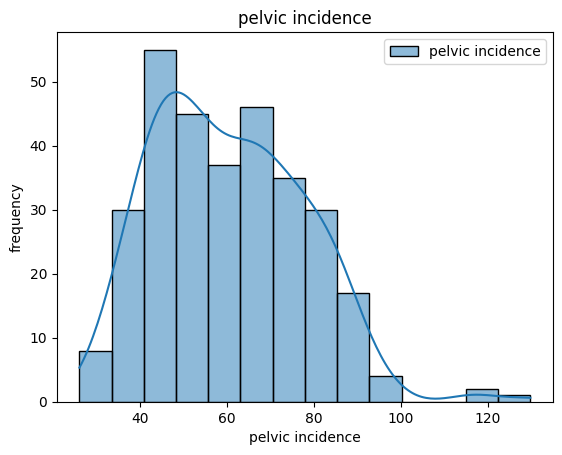

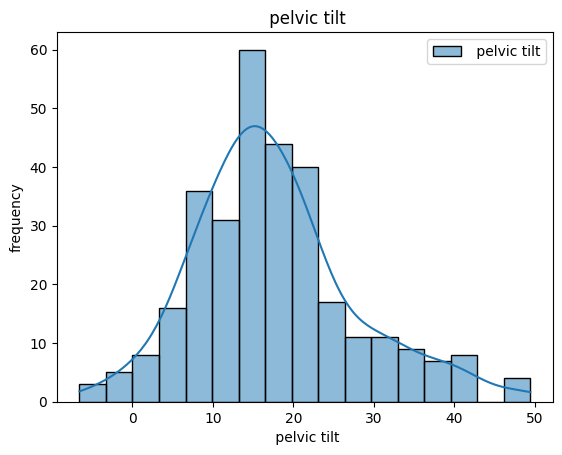

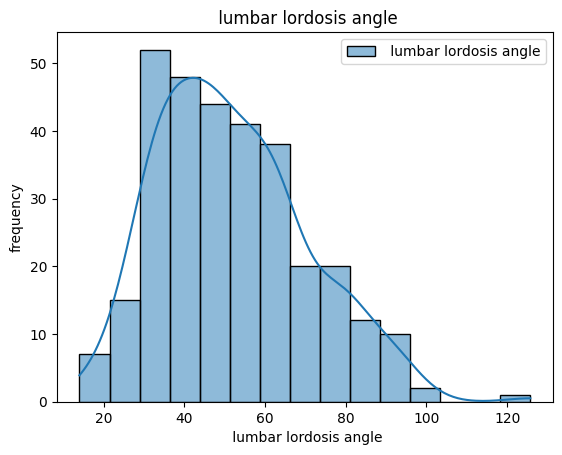

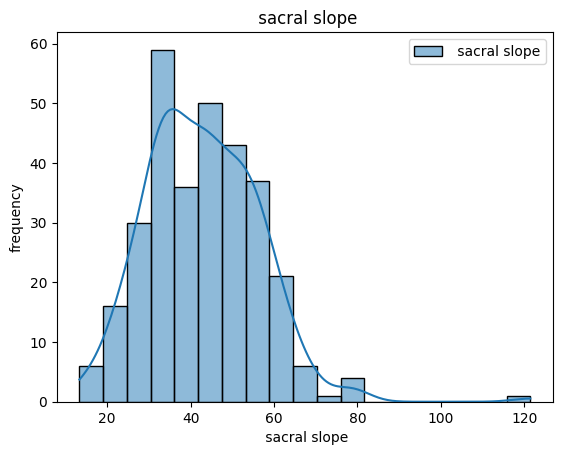

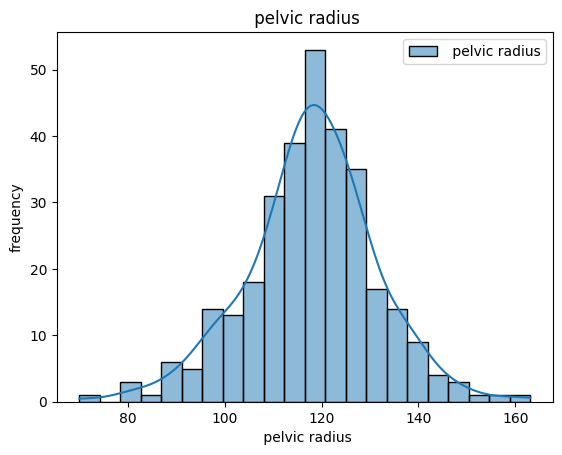

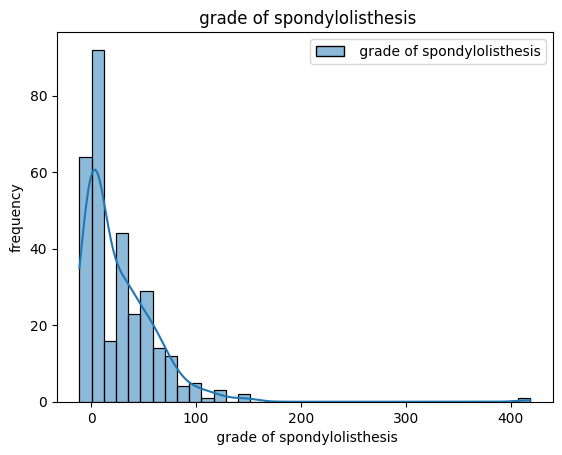

In [10]:
for col in df.columns[:-1]:
    sns.histplot(df[[col]], kde=True)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

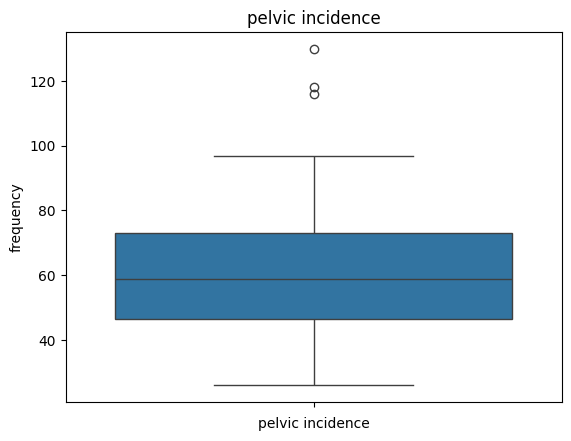

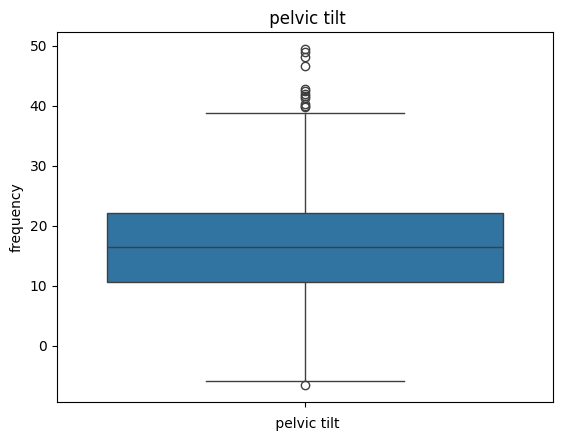

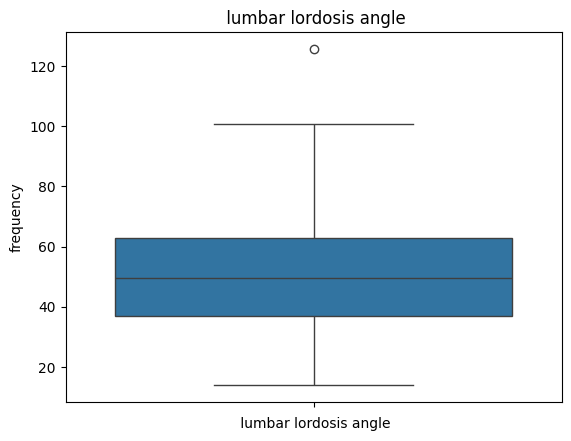

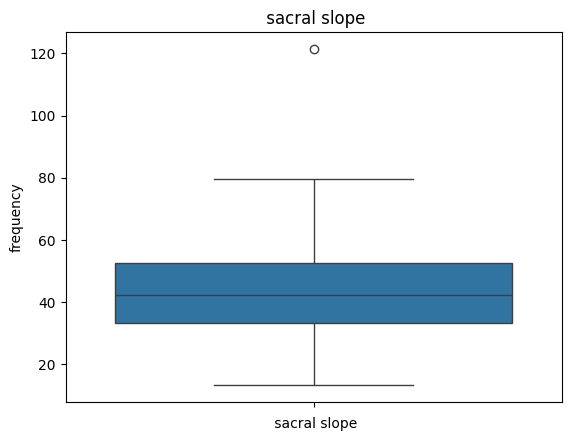

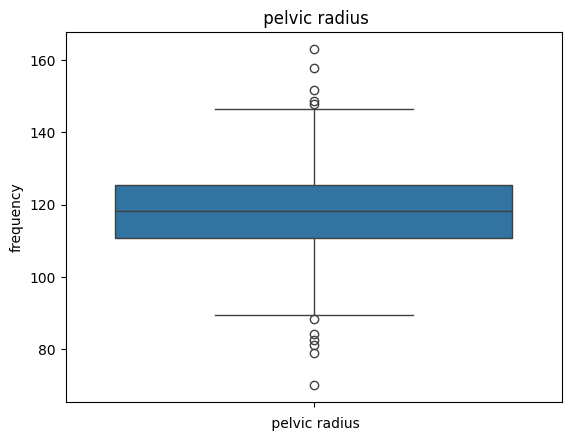

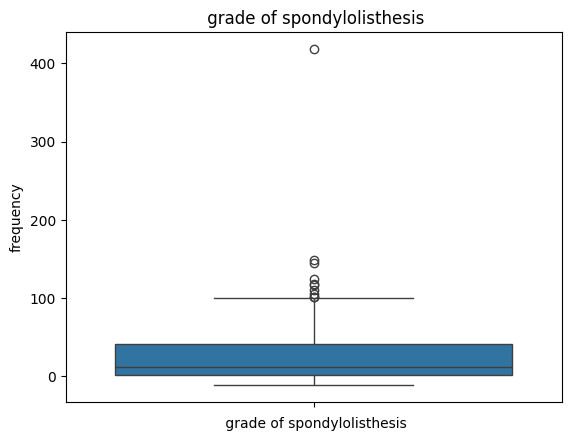

In [11]:
for col in df.columns[:-1]:
    sns.boxplot(df[col])
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

### **4. Data Cleaning**

In [12]:
# Remove spaces from column names

df.columns = df.columns.str.strip()

In [13]:
df.duplicated().sum()

0

In [14]:
# Outlier Remove

for col in df.columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [15]:
print(df.shape)

(276, 7)


In [16]:
df.describe()

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis
count,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000
mean,58.749922,16.119885,50.471788,42.630038,117.982512,20.146843
std,15.666257,8.102616,17.934465,12.498329,11.179399,24.319558
min,26.147921,-5.845994,14.000000,13.366931,89.471834,-11.058179
25%,46.339666,10.490537,36.102696,33.309343,111.206528,1.009837
50%,56.637032,15.739107,47.627403,42.404912,118.353355,7.897616
75%,70.420507,20.741495,61.762922,52.883139,125.205651,35.426657
max,96.657315,38.750670,100.744220,78.794052,145.601033,92.027277


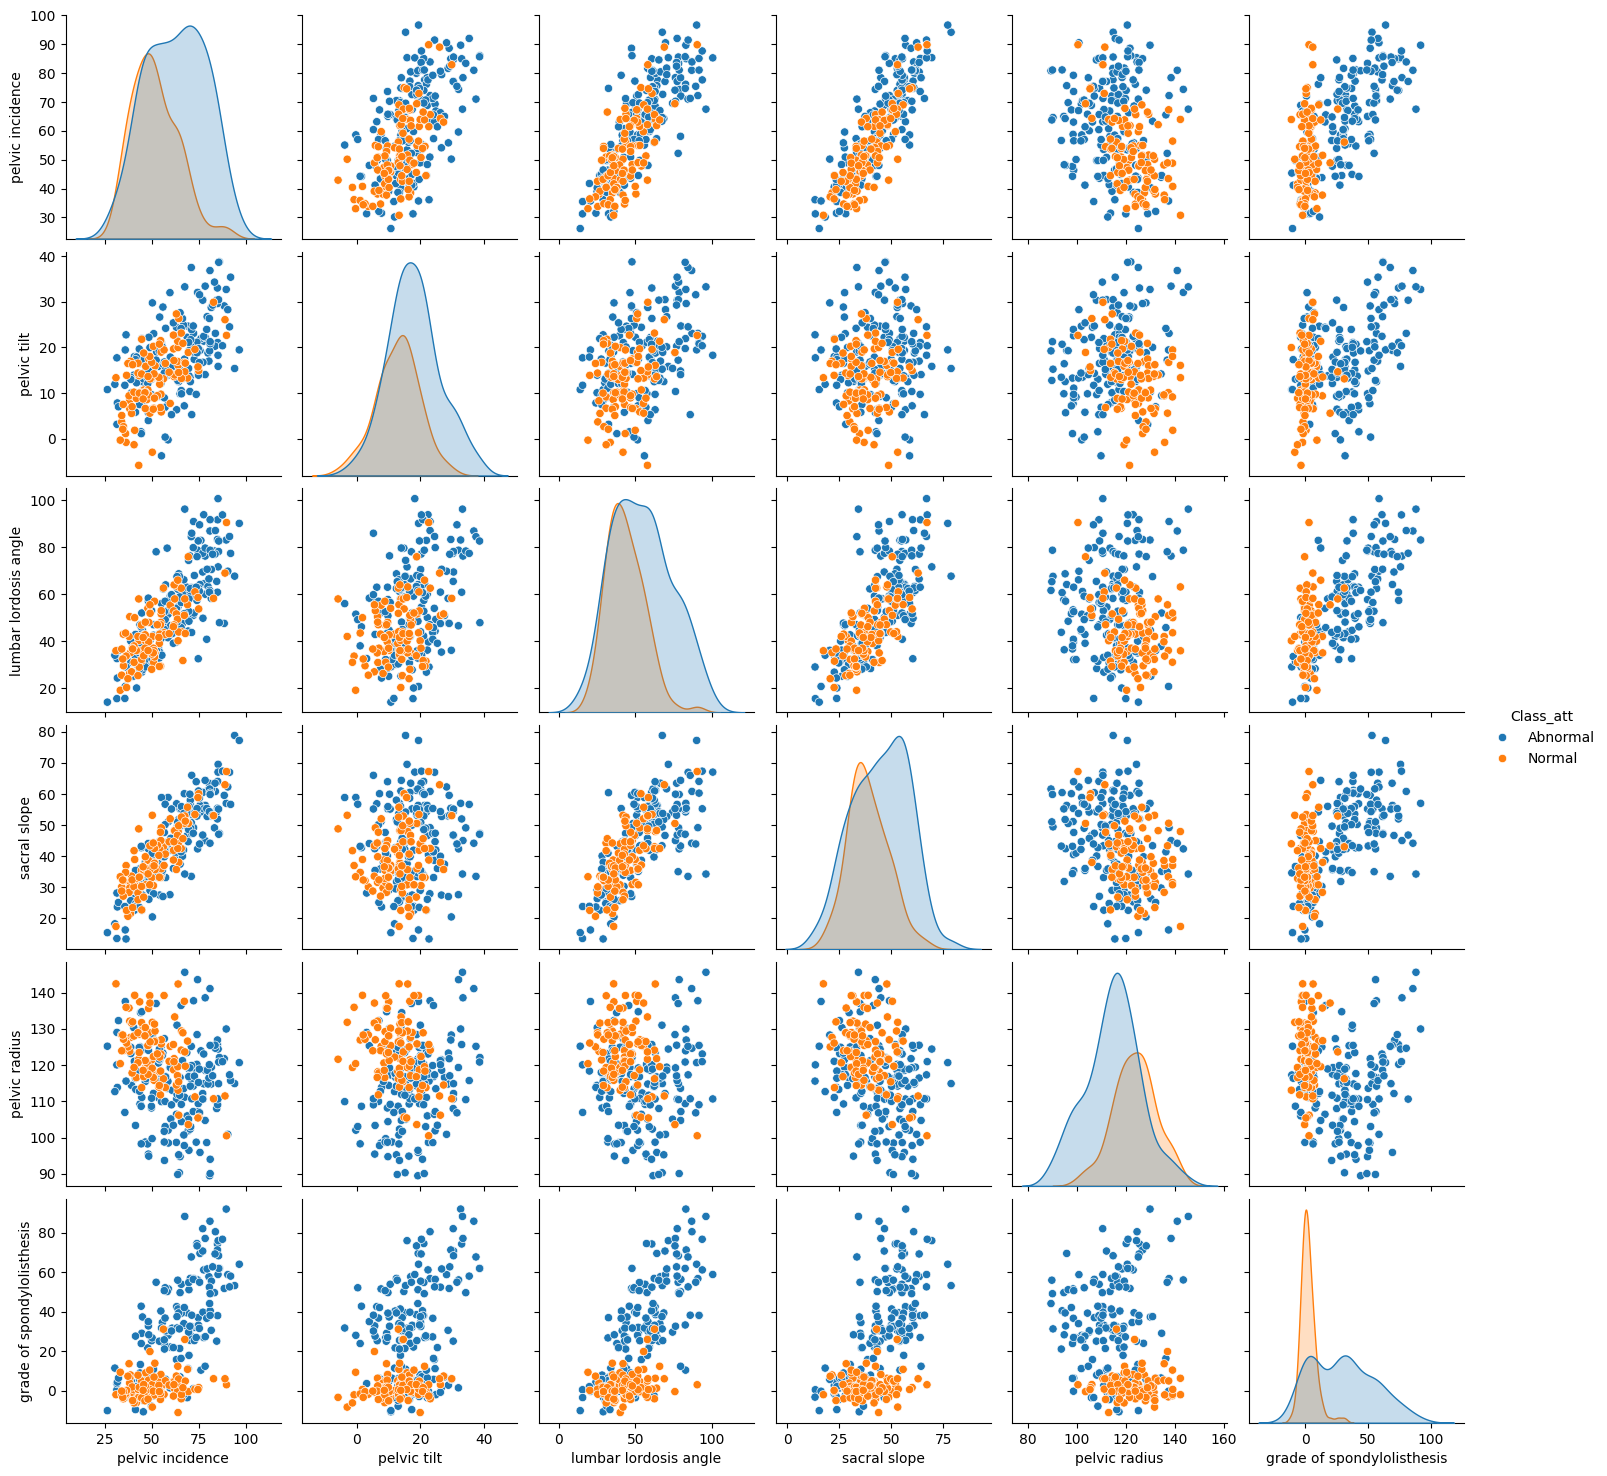

In [17]:
sns.pairplot(data=df, hue="Class_att")
plt.show()

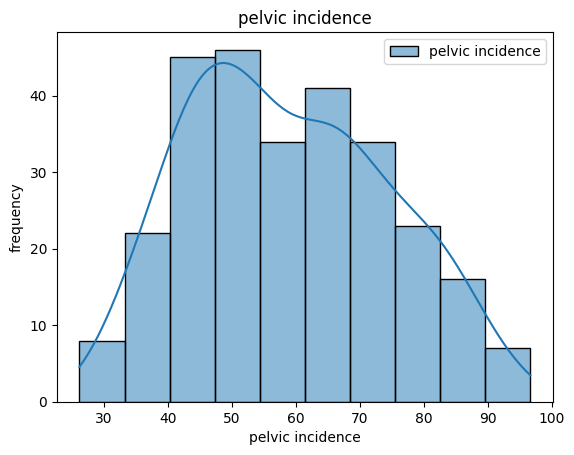

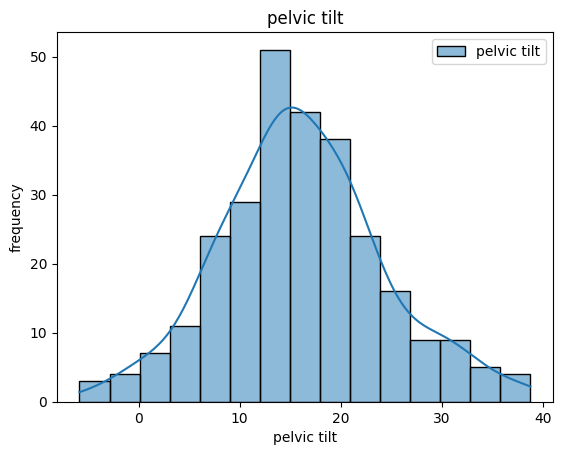

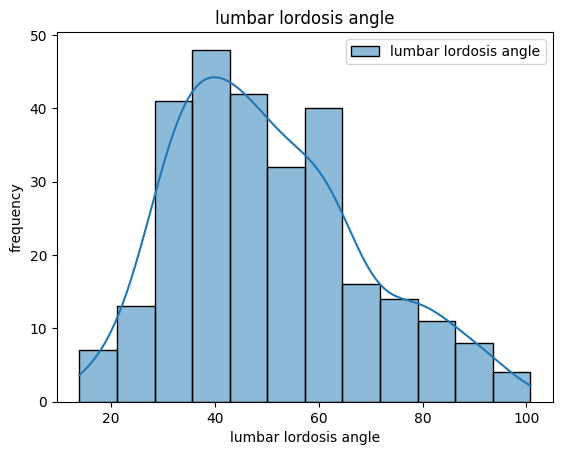

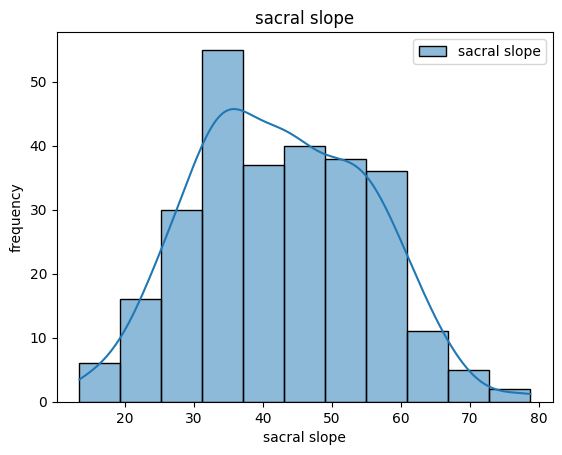

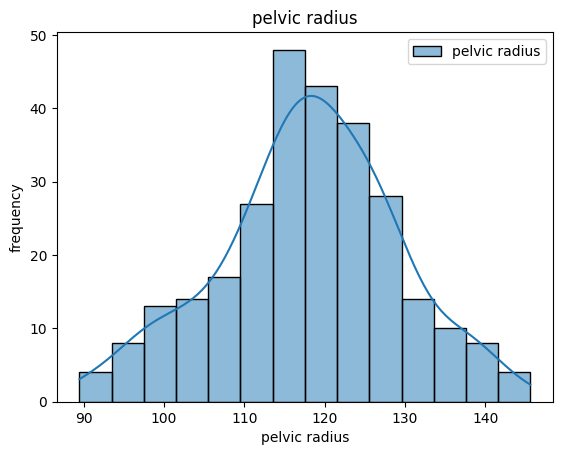

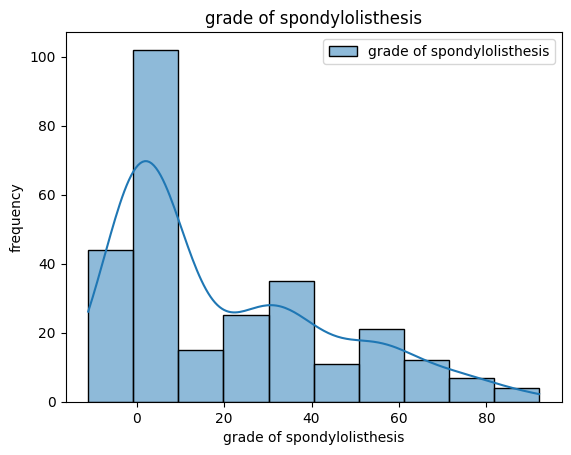

In [18]:
for col in df.columns[:-1]:
    sns.histplot(df[[col]], kde=True)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

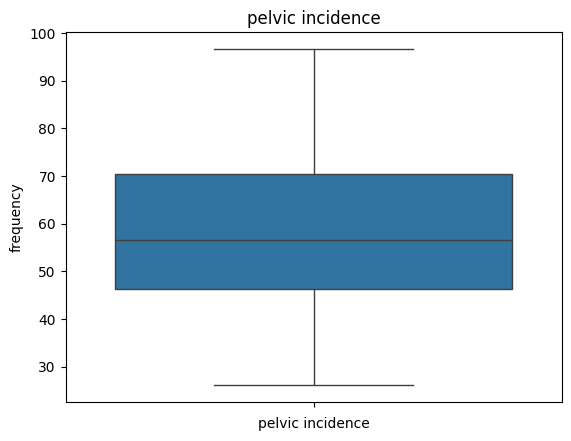

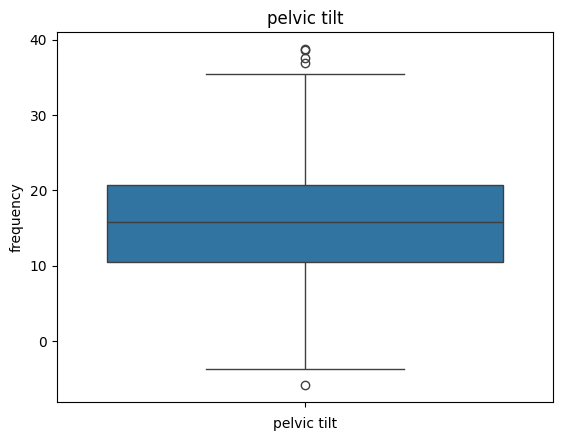

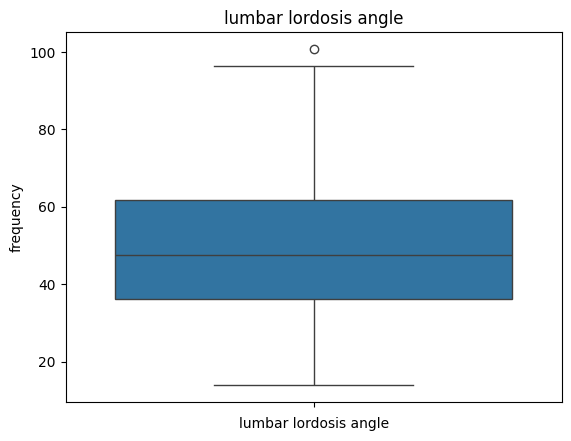

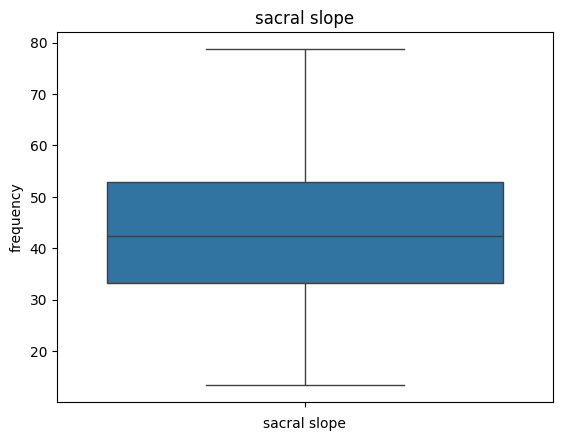

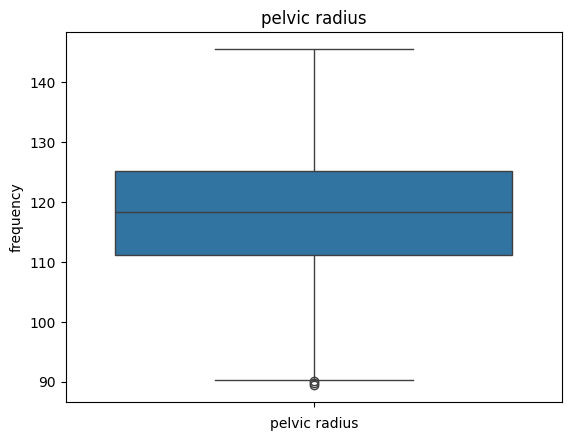

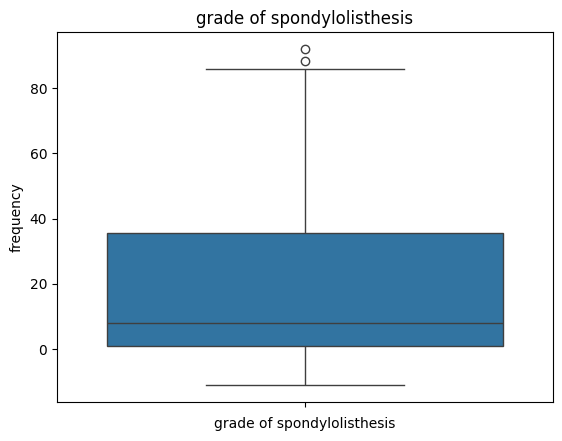

In [19]:
for col in df.columns[:-1]:
    sns.boxplot(df[col])
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

### **6. Data Preprocessing**

In [20]:
df['Class_att'].unique()

array(['Abnormal', 'Normal'], dtype=object)

In [21]:
# Convert the Target column from Decode to Encode

le = LabelEncoder()
df['Class_att'] = le.fit_transform(df['Class_att'])

In [22]:
df['Class_att'].unique()

array([0, 1])

In [23]:
df.head()

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis,Class_att
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,0
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0


In [24]:
scaler = MinMaxScaler()
features = df.columns[:-1]
df[features] = scaler.fit_transform(df[features])

In [25]:
df.head()

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis,Class_att
0,0.523049,0.636787,0.295226,0.414328,0.163927,0.104804,0
1,0.183082,0.356686,0.126987,0.238877,0.444218,0.151548,0
2,0.605368,0.629295,0.416076,0.508147,0.294202,0.073025,0
3,0.611962,0.683882,0.349432,0.478046,0.220859,0.216031,0
4,0.334210,0.347516,0.165053,0.407994,0.333105,0.184087,0


### **7. Feature and Target Split**

In [26]:
x = df.drop(["Class_att"], axis=1)
y = df['Class_att']

### **8. Train-Test Split**

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### **9. Model Building**

In [28]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

### **10. Model Evaluation**

In [29]:
for name, model in models.items():
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    print(f"{name} Accuracy (Training):", model.score(x_train, y_train)*100, "Testing", model.score(x_test, y_test)*100)

Logistic Regression Accuracy (Training): 81.81818181818183 Testing 89.28571428571429
Random Forest Accuracy (Training): 100.0 Testing 85.71428571428571
SVM Accuracy (Training): 86.81818181818181 Testing 83.92857142857143
Decision Tree Accuracy (Training): 100.0 Testing 78.57142857142857
K-Nearest Neighbors Accuracy (Training): 89.54545454545455 Testing 87.5


In [30]:
for name, model in models.items():
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, preds)*100:.2f}")

Logistic Regression Accuracy: 89.29
Random Forest Accuracy: 85.71
SVM Accuracy: 83.93
Decision Tree Accuracy: 82.14
K-Nearest Neighbors Accuracy: 87.50


🔍 Model: Logistic Regression
✅ Accuracy: 89.29%
🎯 Precision Score: 78.95%
🧲 Recall Score: 88.24%
⚖️ F1 Score: 83.33%
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92        39
           1       0.79      0.88      0.83        17

    accuracy                           0.89        56
   macro avg       0.87      0.89      0.88        56
weighted avg       0.90      0.89      0.89        56

🌀 Cross-Validation Accuracy: 80.19% (± 12.03%)


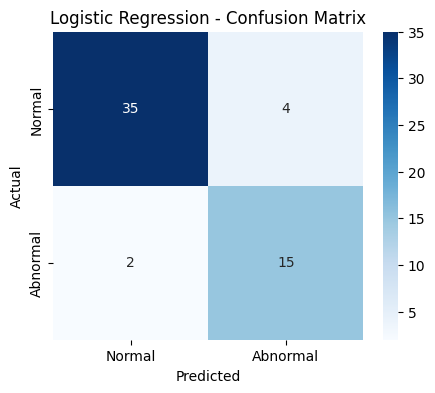

🔍 Model: Random Forest
✅ Accuracy: 82.14%
🎯 Precision Score: 68.42%
🧲 Recall Score: 76.47%
⚖️ F1 Score: 72.22%
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        39
           1       0.68      0.76      0.72        17

    accuracy                           0.82        56
   macro avg       0.79      0.81      0.80        56
weighted avg       0.83      0.82      0.82        56

🌀 Cross-Validation Accuracy: 81.64% (± 13.39%)


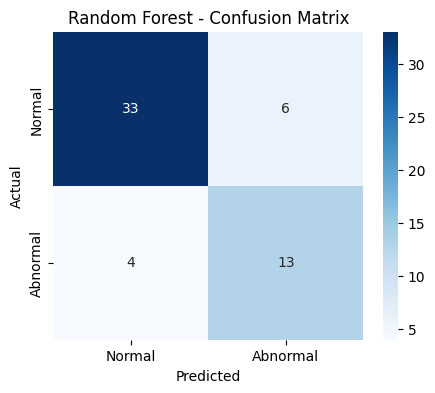

🔍 Model: SVM
✅ Accuracy: 83.93%
🎯 Precision Score: 68.18%
🧲 Recall Score: 88.24%
⚖️ F1 Score: 76.92%
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88        39
           1       0.68      0.88      0.77        17

    accuracy                           0.84        56
   macro avg       0.81      0.85      0.82        56
weighted avg       0.86      0.84      0.84        56

🌀 Cross-Validation Accuracy: 82.00% (± 11.99%)


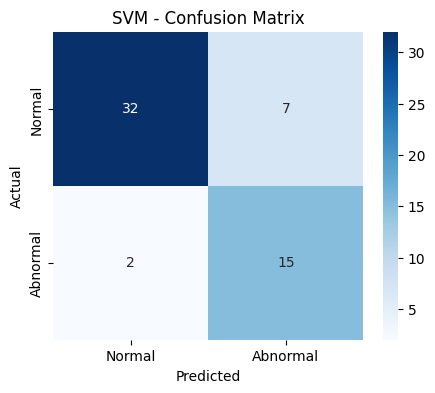

🔍 Model: Decision Tree
✅ Accuracy: 76.79%
🎯 Precision Score: 61.11%
🧲 Recall Score: 64.71%
⚖️ F1 Score: 62.86%
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        39
           1       0.61      0.65      0.63        17

    accuracy                           0.77        56
   macro avg       0.73      0.73      0.73        56
weighted avg       0.77      0.77      0.77        56

🌀 Cross-Validation Accuracy: 74.03% (± 12.13%)


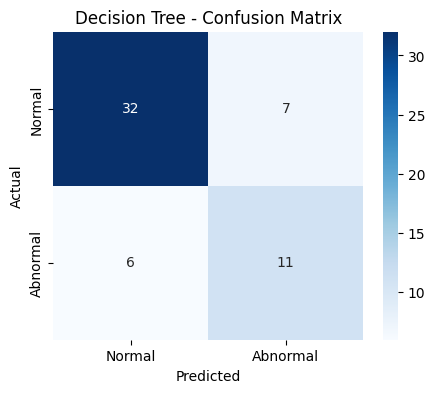

🔍 Model: K-Nearest Neighbors
✅ Accuracy: 87.50%
🎯 Precision Score: 75.00%
🧲 Recall Score: 88.24%
⚖️ F1 Score: 81.08%
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.91        39
           1       0.75      0.88      0.81        17

    accuracy                           0.88        56
   macro avg       0.85      0.88      0.86        56
weighted avg       0.89      0.88      0.88        56

🌀 Cross-Validation Accuracy: 78.81% (± 15.63%)


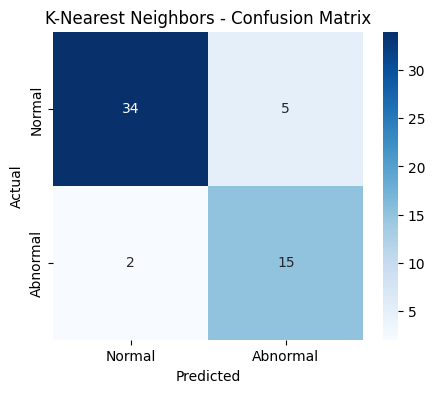

In [31]:
for name, model in models.items():
    print("="*100)
    print(f"🔍 Model: {name}")
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    
    # Accuracy
    acc = accuracy_score(y_test, preds) * 100
    print(f"✅ Accuracy: {acc:.2f}%")

    # Precision Score
    pre = precision_score(y_test, preds) * 100
    print(f"🎯 Precision Score: {pre:.2f}%")

    # Recall Score
    rec = recall_score(y_test, preds) * 100
    print(f"🧲 Recall Score: {rec:.2f}%")

    # F1-Score
    f1 = f1_score(y_test, preds) * 100
    print(f"⚖️ F1 Score: {f1:.2f}%")
    
    # Classification Report
    print("📊 Classification Report:")
    print(classification_report(y_test, preds))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    
    # Cross-validation
    cv_scores = cross_val_score(model, x, y, cv=10)
    print(f"🌀 Cross-Validation Accuracy: {cv_scores.mean()*100:.2f}% (± {cv_scores.std()*100:.2f}%)")

    # Confusion Matrix Visualization
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Abnormal'], 
                yticklabels=['Normal', 'Abnormal'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### **11. Save the Model**

In [32]:
for name, model in models.items():
    model.fit(x_train, y_train)
    
    filename = f"{name.replace(' ', '_')}_model.pkl"
    with open(filename, 'wb') as f:
        pickle.dump(model, f)

### **12. Open the Saved Model**

In [33]:
import os

saved_models = [file for file in os.listdir() if file.endswith(".pkl")]
print("💾 Saved Models:")
for model_file in saved_models:
    print("🗂️", model_file)


💾 Saved Models:
🗂️ Decision_Tree_model.pkl
🗂️ K-Nearest_Neighbors_model.pkl
🗂️ Logistic_Regression_model.pkl
🗂️ Random_Forest_model.pkl
🗂️ SVM_model.pkl


### **13. Open the Loaded Models**

In [34]:
for model_file in saved_models:
    with open(model_file, 'rb') as f:
        loaded_model = pickle.load(f)
    print(f"📦 Loaded: {model_file}")
    print(f"🧠 Model Type: {type(loaded_model)}")
    print()

📦 Loaded: Decision_Tree_model.pkl
🧠 Model Type: <class 'sklearn.tree._classes.DecisionTreeClassifier'>

📦 Loaded: K-Nearest_Neighbors_model.pkl
🧠 Model Type: <class 'sklearn.neighbors._classification.KNeighborsClassifier'>

📦 Loaded: Logistic_Regression_model.pkl
🧠 Model Type: <class 'sklearn.linear_model._logistic.LogisticRegression'>

📦 Loaded: Random_Forest_model.pkl
🧠 Model Type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>

📦 Loaded: SVM_model.pkl
🧠 Model Type: <class 'sklearn.svm._classes.SVC'>



### **14. Prediction for Given Samples**

In [35]:
# Test Sample

sample = x_test.iloc[42].values.reshape(1, -1)
print(sample)

[[0.46024516 0.12522227 0.43230546 0.69534003 0.22396502 0.37947037]]


In [36]:
# Actual Test Output

predicted_class = model.predict(sample)
print("Predicted Class:", predicted_class[0])

Predicted Class: 0


In [37]:
# Predicted Test Output (Each Algorithm)

sample = x_test.iloc[42].values.reshape(1, -1)

for model_file in saved_models:
    with open(model_file, 'rb') as f:
        model = pickle.load(f)
    prediction = model.predict(sample)
    print(f"🔮 {model_file} → Prediction: {prediction}")

🔮 Decision_Tree_model.pkl → Prediction: [0]
🔮 K-Nearest_Neighbors_model.pkl → Prediction: [0]
🔮 Logistic_Regression_model.pkl → Prediction: [0]
🔮 Random_Forest_model.pkl → Prediction: [0]
🔮 SVM_model.pkl → Prediction: [0]


In [38]:
sample = x_test.iloc[42].values.reshape(1, -1)
label_map = {0: 'Normal', 1: 'Abnormal'}

for model_file in saved_models:
    with open(model_file, 'rb') as f:
        model = pickle.load(f)
    prediction = model.predict(sample)[0]
    label = label_map[prediction]
    print(f"🔮 {model_file} → Prediction: {label}")

🔮 Decision_Tree_model.pkl → Prediction: Normal
🔮 K-Nearest_Neighbors_model.pkl → Prediction: Normal
🔮 Logistic_Regression_model.pkl → Prediction: Normal
🔮 Random_Forest_model.pkl → Prediction: Normal
🔮 SVM_model.pkl → Prediction: Normal


### **15. Conclusion**

The Logistic Regression model achieved good accuracy in predicting spine conditions. Further improvements can be made by hyperparameter tuning and feature engineering.

### **16. Future Work**

- Try advanced models like XGBoost.
- Collect more patient data.
- Perform feature selection techniques.
- Deploy model for real-time prediction.

📂 GitHub/Colab/Notebook: [Attach Link]<br>
🤝 Let’s connect if you're working on or hiring for healthtech or ML-based applications!